Extrayendo muestra representativa del 10%...
Calculando Inercia (WCSS) para el Método del Codo...
Esto tomará unos minutos, por favor espera...

 -> Evaluación con K=10 completada.
 -> Evaluación con K=30 completada.
 -> Evaluación con K=50 completada.
 -> Evaluación con K=70 completada.
 -> Evaluación con K=90 completada.
 -> Evaluación con K=110 completada.
 -> Evaluación con K=130 completada.
 -> Evaluación con K=150 completada.
 -> Evaluación con K=170 completada.
 -> Evaluación con K=190 completada.


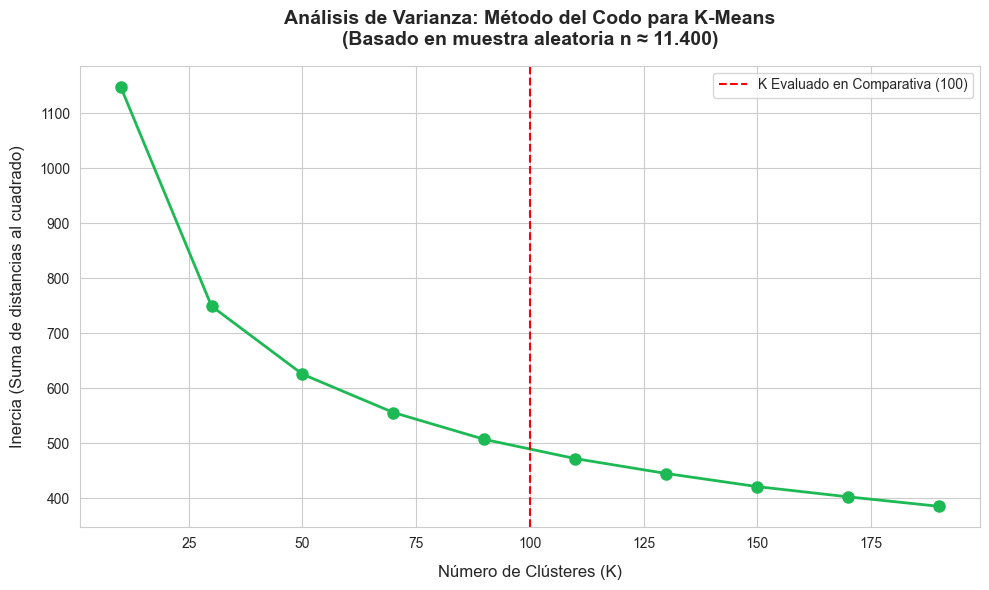

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Extraer una muestra aleatoria del 10% del dataset
print("Extrayendo muestra representativa del 10%...")
df_muestra = df.sample(frac=0.1, random_state=42)

# Definir las variables espaciales
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X_muestra = df_muestra[features].values

# 2. Rango de Clústeres a evaluar (De 10 a 200, saltando de 20 en 20)
k_values = range(10, 210, 20)
inercias = []

print("Calculando Inercia (WCSS) para el Método del Codo...")
print("Esto tomará unos minutos, por favor espera...\n")

for k in k_values:
    # Entrenamos el modelo temporal solo con la muestra
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_muestra)
    inercias.append(kmeans_temp.inertia_)
    print(f" -> Evaluación con K={k} completada.")

# 3. Graficar los resultados con estilo académico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Dibujar la curva
plt.plot(k_values, inercias, marker='o', linestyle='-', color='#1DB954', linewidth=2, markersize=8) # Verde Spotify

# Personalización del gráfico
plt.title('Análisis de Varianza: Método del Codo para K-Means\n(Basado en muestra aleatoria n ≈ 11.400)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12, labelpad=10)
plt.ylabel('Inercia (Suma de distancias al cuadrado)', fontsize=12, labelpad=10)

# Marcar el punto que usaremos en la comparativa (ej. K=100)
plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='K Evaluado en Comparativa (100)')

plt.legend()
plt.tight_layout()
plt.show()

Configuración y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import time
import sys
from sklearn.cluster import KMeans

# 1. Importar el evaluador oficial del equipo
sys.path.append('../src')
try:
    from evaluador import evaluar_modelo_recomendacion
except ImportError:
    print("⚠️ No se encontró evaluador.py. Asegúrate de estar ejecutando desde la carpeta correcta.")

# 2. Carga de datos (Usar ruta relativa para que funcione en cualquier PC del equipo)
ruta_csv = "C:/Users/basti/proyecto_cd/data/processed/spotify_dataset_processed.csv"
df = pd.read_csv(ruta_csv)

# 3. Definición de las variables espaciales
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Matriz de características puras
X = df[features].values
print(f"Dataset cargado. Forma de la matriz espacial: {X.shape}")

Dataset cargado. Forma de la matriz espacial: (81343, 9)


Entrenamiento de Modelo K-Means

In [2]:
print("Entrenando modelo K-Means (Agrupación Estática)...")

# Configuramos K-Means para crear 100 grupos musicales
kmeans = KMeans(n_clusters=100, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X)

print("¡K-Means entrenado! Cada canción ha sido encerrada en uno de los 100 clústeres.")

Entrenando modelo K-Means (Agrupación Estática)...
¡K-Means entrenado! Cada canción ha sido encerrada en uno de los 100 clústeres.


In [3]:
def buscar_cancion_id(nombre, dataset, artista=None):
    """
    Busca el track_id de una canción por nombre (y artista opcional).
    """
    # Busqueda insensible a mayúsculas
    if artista:
        resultado = dataset[(dataset['track_name'].str.lower() == nombre.lower()) & 
                            (dataset['artists'].str.lower() == artista.lower())]
    else:
        resultado = dataset[dataset['track_name'].str.lower() == nombre.lower()]
    
    if resultado.empty:
        print(f"❌ No se encontró la canción: '{nombre}'")
        return None
    
    # Si hay varios, tomamos el primero y avisamos
    if len(resultado) > 1 and not artista:
        print(f"⚠️ Se encontraron varias versiones de '{nombre}'. Usando la de {resultado.iloc[0]['artists']}.")
    
    return resultado.iloc[0]['track_id']

In [4]:
def probar_kmeans_y_evaluar(track_id, dataset, features_list, top_k=5):
    inicio_tiempo = time.time() # Iniciamos cronómetro para el KPI de Latencia

    # Buscar la canción por su ID universal
    cancion_semilla = dataset[dataset['track_id'] == track_id]
    if cancion_semilla.empty:
        return "Canción no encontrada."

    nombre = cancion_semilla['track_name'].values[0]
    artista = cancion_semilla['artists'].values[0]
    vector_semilla = cancion_semilla[features_list] # Extraemos el vector para el evaluador

    print(f"🎵 CANCIÓN SEMILLA: '{nombre}' - {artista}\n")
    print("-" * 50)

    # Buscamos a qué clúster pertenece la semilla
    cluster_semilla = cancion_semilla['cluster_kmeans'].values[0]

    # Filtramos todas las canciones del mismo clúster (excluyendo la semilla)
    canciones_mismo_cluster = dataset[(dataset['cluster_kmeans'] == cluster_semilla) & (dataset['track_id'] != track_id)]

    # Tomamos 5 canciones aleatorias de ese clúster como recomendación
    if len(canciones_mismo_cluster) >= top_k:
        recomendaciones_kmeans = canciones_mismo_cluster.sample(n=top_k, random_state=42)
    else:
        recomendaciones_kmeans = canciones_mismo_cluster

    # Extraemos los vectores matemáticos de las recomendadas
    vectores_recomendados = recomendaciones_kmeans[features_list]
    fin_tiempo = time.time() # Detenemos cronómetro

    print("🤖 RECOMENDACIONES K-MEANS (Mismo Clúster):")
    for idx, cancion in recomendaciones_kmeans.iterrows():
        print(f" -> {cancion['track_name']} - {cancion['artists']} | Género: {cancion['track_genre']}")

    # ==========================================
    # ENVIAMOS LOS DATOS AL EVALUADOR DEL EQUIPO
    # ==========================================
    evaluar_modelo_recomendacion("K-Means (Clustering Global)", vector_semilla, vectores_recomendados, inicio_tiempo, fin_tiempo)

    return recomendaciones_kmeans

Ejecutar la comparacion de los Modelos

In [5]:
# OJO AQUÍ: Deben usar exactamente el mismo track_id que usaste tú en el KNN
# Para asegurar que la semilla sea la misma, la extraemos por índice si es necesario, 
# pero le pasamos el 'track_id' a la función.
test_track_id = df['track_id'].iloc[1000] # O el índice que hayan acordado probar

resultados_kmeans = probar_kmeans_y_evaluar(test_track_id, df, features)

🎵 CANCIÓN SEMILLA: 'Me Dê Motivo' - Criolo

--------------------------------------------------
🤖 RECOMENDACIONES K-MEANS (Mismo Clúster):
 -> Chappa Fi True - Nervz;Navaz | Género: dancehall
 -> Una Pura Y Dos Con Sal - Cuco Sánchez | Género: guitar
 -> 热爱105°C的你 - A Si | Género: mandopop
 -> Itsy Bitsy Spider - Itsy Bitsy Spider Kids | Género: children
 -> Piç - Peyk | Género: j-rock

=== EVALUACIÓN DEL MODELO: K-Means (Clustering Global) ===
⏱️ KPI Latencia: 0.0202 segundos
📏 KPI Distancia Acústica Promedio: 0.0092
✅ Resultado: ÉXITO (Recomendaciones altamente coherentes)

